In [1]:
import glob
import os
import torch
torch.cuda.empty_cache()
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import cv2
import time

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:512"

C:\Users\Edward\anaconda3\envs\Eidolon\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\Edward\anaconda3\envs\Eidolon\lib\site-packages\numpy\.libs\libopenblas.GK7GX5KEQ4F6UYO3P26ULGBQYHGQO7J4.gfortran-win_amd64.dll
C:\Users\Edward\anaconda3\envs\Eidolon\lib\site-packages\numpy\.libs\libopenblas.PYQHXLVVQ7VESDPUVUADXEVJOBGHJPAY.gfortran-win_amd64.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [2]:
from torchvision.datasets.vision import VisionDataset
from torch.utils.data import IterableDataset
from torchvision.datasets.video_utils import VideoClips
# from video_clip import VideoClips
import torch.utils.data as data
from bat_seg_models import ThreeLayerSemSegNetWideView, UNET, UNETTraditional
from frame_augmentors import MaskNormalize, Mask3dto2d, AddDim, ToFloat, MaskCompose, MaskToTensor
import bat_functions
from CountLine import CountLine

In [3]:
import matplotlib.pyplot as plt
im_file = "D:/kasanka-bats/30-Oct-2020/BBC/example-frames/30-Oct-2020_BBC_obs-ind_28350.jpg"
#im_file = ".../kasanka-bats/frames/17Nov/card-f/GP039791/GP039791_15948.jpg"
im = plt.imread(im_file)

im.shape

(1516, 2700)

In [4]:
# ask AI what is wrong here

root_output_folder = 'D:\\kasanka-bats'
# date = '20211221'
days = ["30-Oct-2020"]
# os.makedirs(root_output_folder, exist_ok=True)

camera_folders = []
for day in days:
    raw_camera_folders = []
    print(day)
    day_camera_folders = sorted(glob.glob(os.path.join('F:\\KasankaCameras', day, "*"))) # Puku*
    raw_camera_folders.extend(day_camera_folders)
    #day_camera_folders = sorted(glob.glob(os.path.join('K:\\KasankaCameras', day, "MusolaTower*")))
    #raw_camera_folders.extend(day_camera_folders)
    #day_camera_folders = sorted(glob.glob(os.path.join('K:\\KasankaCameras', day, "MusolaPath2*")))
    #raw_camera_folders.extend(day_camera_folders)
    #day_camera_folders = sorted(glob.glob(os.path.join('K:\\KasankaCameras', day, "Sunset*")))
    #raw_camera_folders.extend(day_camera_folders)
    
    for camera_folder in raw_camera_folders:
        videos = sorted(glob.glob(os.path.join(camera_folder, '*.[Mm][Pp]4')))
        camera_name = camera_folder.split('\\')[-1]
        if not os.path.exists(os.path.join(root_output_folder, day, camera_name, 'centers.npy')):
            camera_folders.append(camera_folder)
            print(camera_folder)
            print('--------------')
            
            
camera_folders = list(set(camera_folders))
print(camera_folders)

30-Oct-2020
F:\KasankaCameras\30-Oct-2020\Chinyangali
--------------
F:\KasankaCameras\30-Oct-2020\Fibwe Parking
--------------
F:\KasankaCameras\30-Oct-2020\Fibwe Public
--------------
F:\KasankaCameras\30-Oct-2020\Musola Parking
--------------
F:\KasankaCameras\30-Oct-2020\Musola Path
--------------
F:\KasankaCameras\30-Oct-2020\Not Chingyangali
--------------
F:\KasankaCameras\30-Oct-2020\Puku
--------------
['F:\\KasankaCameras\\30-Oct-2020\\Not Chingyangali', 'F:\\KasankaCameras\\30-Oct-2020\\Fibwe Parking', 'F:\\KasankaCameras\\30-Oct-2020\\Musola Parking', 'F:\\KasankaCameras\\30-Oct-2020\\Chinyangali', 'F:\\KasankaCameras\\30-Oct-2020\\Fibwe Public', 'F:\\KasankaCameras\\30-Oct-2020\\Puku', 'F:\\KasankaCameras\\30-Oct-2020\\Musola Path']


In [5]:
print(camera_folders)


['F:\\KasankaCameras\\30-Oct-2020\\Not Chingyangali', 'F:\\KasankaCameras\\30-Oct-2020\\Fibwe Parking', 'F:\\KasankaCameras\\30-Oct-2020\\Musola Parking', 'F:\\KasankaCameras\\30-Oct-2020\\Chinyangali', 'F:\\KasankaCameras\\30-Oct-2020\\Fibwe Public', 'F:\\KasankaCameras\\30-Oct-2020\\Puku', 'F:\\KasankaCameras\\30-Oct-2020\\Musola Path']


In [6]:
class BatIterableDataset(IterableDataset):
    def __init__(self, video_files, augmentor=None, max_bad_reads=300):
        self.vid_cap = cv2.VideoCapture(video_files[0])
        self.video_files = video_files
        assert self.vid_cap.isOpened()
        self.more_frames = True
        # How many times a frame can come up false 
        # before assuming end of video
        self.max_bad_reads = max_bad_reads
        self.total_frames_read = 0
        self.total_bad_reads = 0
        self.augmentor = augmentor
        self.video_number = 0
        
    def more_videos(self):
        return self.video_number < len(self.video_files)
    
    def start_next_video(self):
        if self.vid_cap.isOpened():
            self.vid_cap.release()
        self.video_number += 1
        if self.video_number < len(self.video_files):
            print('starting new video')
            print(self.get_read_frame_info())
            self.vid_cap = cv2.VideoCapture(self.video_files[self.video_number])
        
    def video_generator(self):
        while(self.vid_cap.isOpened() or self.more_videos()):
            if not self.vid_cap.isOpened():
                self.start_next_video()
            good_read = False
            num_bad_reads = 0
            while (not good_read and (num_bad_reads < self.max_bad_reads)):
                grabbed, frame = self.vid_cap.read()
                if grabbed:
                    good_read = True
                    self.total_frames_read += 1
                    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    frame = {'image': frame[2:-2, 2:-2]}
                    if np.mean(frame['image'][::50,::50, 2]) < 5:
                        print('too dark')
                        self.vid_cap.release()
                        break
                        
                    if self.augmentor:
                        frame = self.augmentor(frame)
                    yield frame
                else:
                    num_bad_reads += 1
                    self.total_bad_reads += 1
            if not good_read:
                self.vid_cap.release()
                print("video capture closed")
            
    def __iter__(self):
        return self.video_generator()
    
    def __del__(self):
        if self.vid_cap.isOpened():
            self.vid_cap.release()
    
    def is_more_frames(self):
        return self.vid_cap.isOpened()
    
    def get_read_frame_info(self):
        print('{} frames have been read with {} bad reads'.format(self.total_frames_read,
                                                                  self.total_bad_reads))

In [7]:
#folder = './models'
folder = 'C:/Users/Edward/Dropbox/bats-code/models'

# model_filename = 'model_ThreeLayerWide_epochs_10_batcheff_4_lr_0.05_momentum_0.5_aug_aug-no-blur-2d-17Nov-big-dataset.tar'
# model_filename = 'model_UNET_epochs_100_batcheff_16_lr_0.01_momentum_0.9_aug_aug-2d-20Nov-big-dataset.tar'
# model_filename = 'model_UNET_epochs_100_batcheff_16_lr_0.01_momentum_0.9_aug_better-norm-aug-2d-20Nov-big-dataset.tar'
# model_file = os.path.join(folder, model_filename)
# model_file = './models/model_UNETTraditional_epochs_100_batcheff_16_lr_0.01_momentum_0.9_aug_better-norm-aug-2d-20Nov-big-dataset.tar'
# model_filename = 'model_UNET_epochs_100_batcheff_16_lr_0.01_momentum_0.9_aug_aug-2d-20Nov-big-dataset.tar'
# model_filename = 'model_UNET_epochs_100_batcheff_16_lr_0.01_momentum_0.9_aug_better-norm-aug-2d-20Nov-big-dataset.tar'
# model_filename = 'model_UNETTraditional_epochs_10_batcheff_16_lr_0.01_momentum_0.9_aug_better-norm-aug-2d-20Nov-big-dataset.tar'
model_filename = 'model_UNETTraditional_epochs_100_batcheff_16_lr_0.01_momentum_0.9_aug_better-norm-aug-2d-20Nov-big-dataset.tar'
#model_file = os.path.join(folder, model_filename)
model_file = os.path.join(folder.replace("\\", "/"), model_filename)

# device = torch.device("cuda")
# model = UNET(1, 2, should_pad=False)
# model.load_state_dict(torch.load(model_file))
# model.to(device)


In [8]:
#model = UNET(1, 2, should_pad=False)
#print(model.state_dict().keys())


In [9]:
#root_train_folder = ".../kasanka-bats/annotations"
root_train_folder = r"C:\Users\Edward\Dropbox\bats-code\data"
mean = np.load(os.path.join(root_train_folder, 'mean.npy'))
std = np.load(os.path.join(root_train_folder, 'std.npy'))

channel = 2
       
# augmentor = None
bat_datasets = []
for camera_folder in camera_folders:
    videos = sorted(glob.glob(os.path.join(camera_folder, '*.[Mm][Pp]4')))
    if not videos:
        continue
    # print(videos)
    augmentor = MaskCompose([Mask3dto2d(channel_to_use=channel),
                         MaskToTensor(),
                         MaskNormalize(mean[channel]/255, std[channel]/255),
                        ])
    bat_dataset = BatIterableDataset(videos, augmentor=augmentor)
    #print(camera_folder.split('\\')[-2:])
    save_folder = os.path.join(root_output_folder, *camera_folder.split('\\')[-2:])
    #print(save_folder)
    os.makedirs(save_folder, exist_ok=True)
    os.makedirs(os.path.join(save_folder, 'example-frames'), exist_ok=True)
    bat_datasets.append({'dataset':bat_dataset,
                         'save_folder': save_folder})
                                    

In [10]:
for i in bat_datasets[0]['dataset']:
    break
# dataloader = data.DataLoader(bat_dataset['dataset'], 
#                                  batch_size=batch_size,
#                                  shuffle=False, num_workers=0, 
#                                  pin_memory=True)

In [11]:
print(camera_folders)

['F:\\KasankaCameras\\30-Oct-2020\\Not Chingyangali', 'F:\\KasankaCameras\\30-Oct-2020\\Fibwe Parking', 'F:\\KasankaCameras\\30-Oct-2020\\Musola Parking', 'F:\\KasankaCameras\\30-Oct-2020\\Chinyangali', 'F:\\KasankaCameras\\30-Oct-2020\\Fibwe Public', 'F:\\KasankaCameras\\30-Oct-2020\\Puku', 'F:\\KasankaCameras\\30-Oct-2020\\Musola Path']


In [12]:
print(bat_datasets)

[{'dataset': <__main__.BatIterableDataset object at 0x0000013EA7374340>, 'save_folder': 'D:\\kasanka-bats\\30-Oct-2020\\Not Chingyangali'}, {'dataset': <__main__.BatIterableDataset object at 0x0000013EA73744F0>, 'save_folder': 'D:\\kasanka-bats\\30-Oct-2020\\Fibwe Parking'}, {'dataset': <__main__.BatIterableDataset object at 0x0000013EA73746D0>, 'save_folder': 'D:\\kasanka-bats\\30-Oct-2020\\Musola Parking'}, {'dataset': <__main__.BatIterableDataset object at 0x0000013EA73744C0>, 'save_folder': 'D:\\kasanka-bats\\30-Oct-2020\\Chinyangali'}, {'dataset': <__main__.BatIterableDataset object at 0x0000013EA73749A0>, 'save_folder': 'D:\\kasanka-bats\\30-Oct-2020\\Fibwe Public'}, {'dataset': <__main__.BatIterableDataset object at 0x0000013EA7374B80>, 'save_folder': 'D:\\kasanka-bats\\30-Oct-2020\\Puku'}, {'dataset': <__main__.BatIterableDataset object at 0x0000013EA7374D30>, 'save_folder': 'D:\\kasanka-bats\\30-Oct-2020\\Musola Path'}]


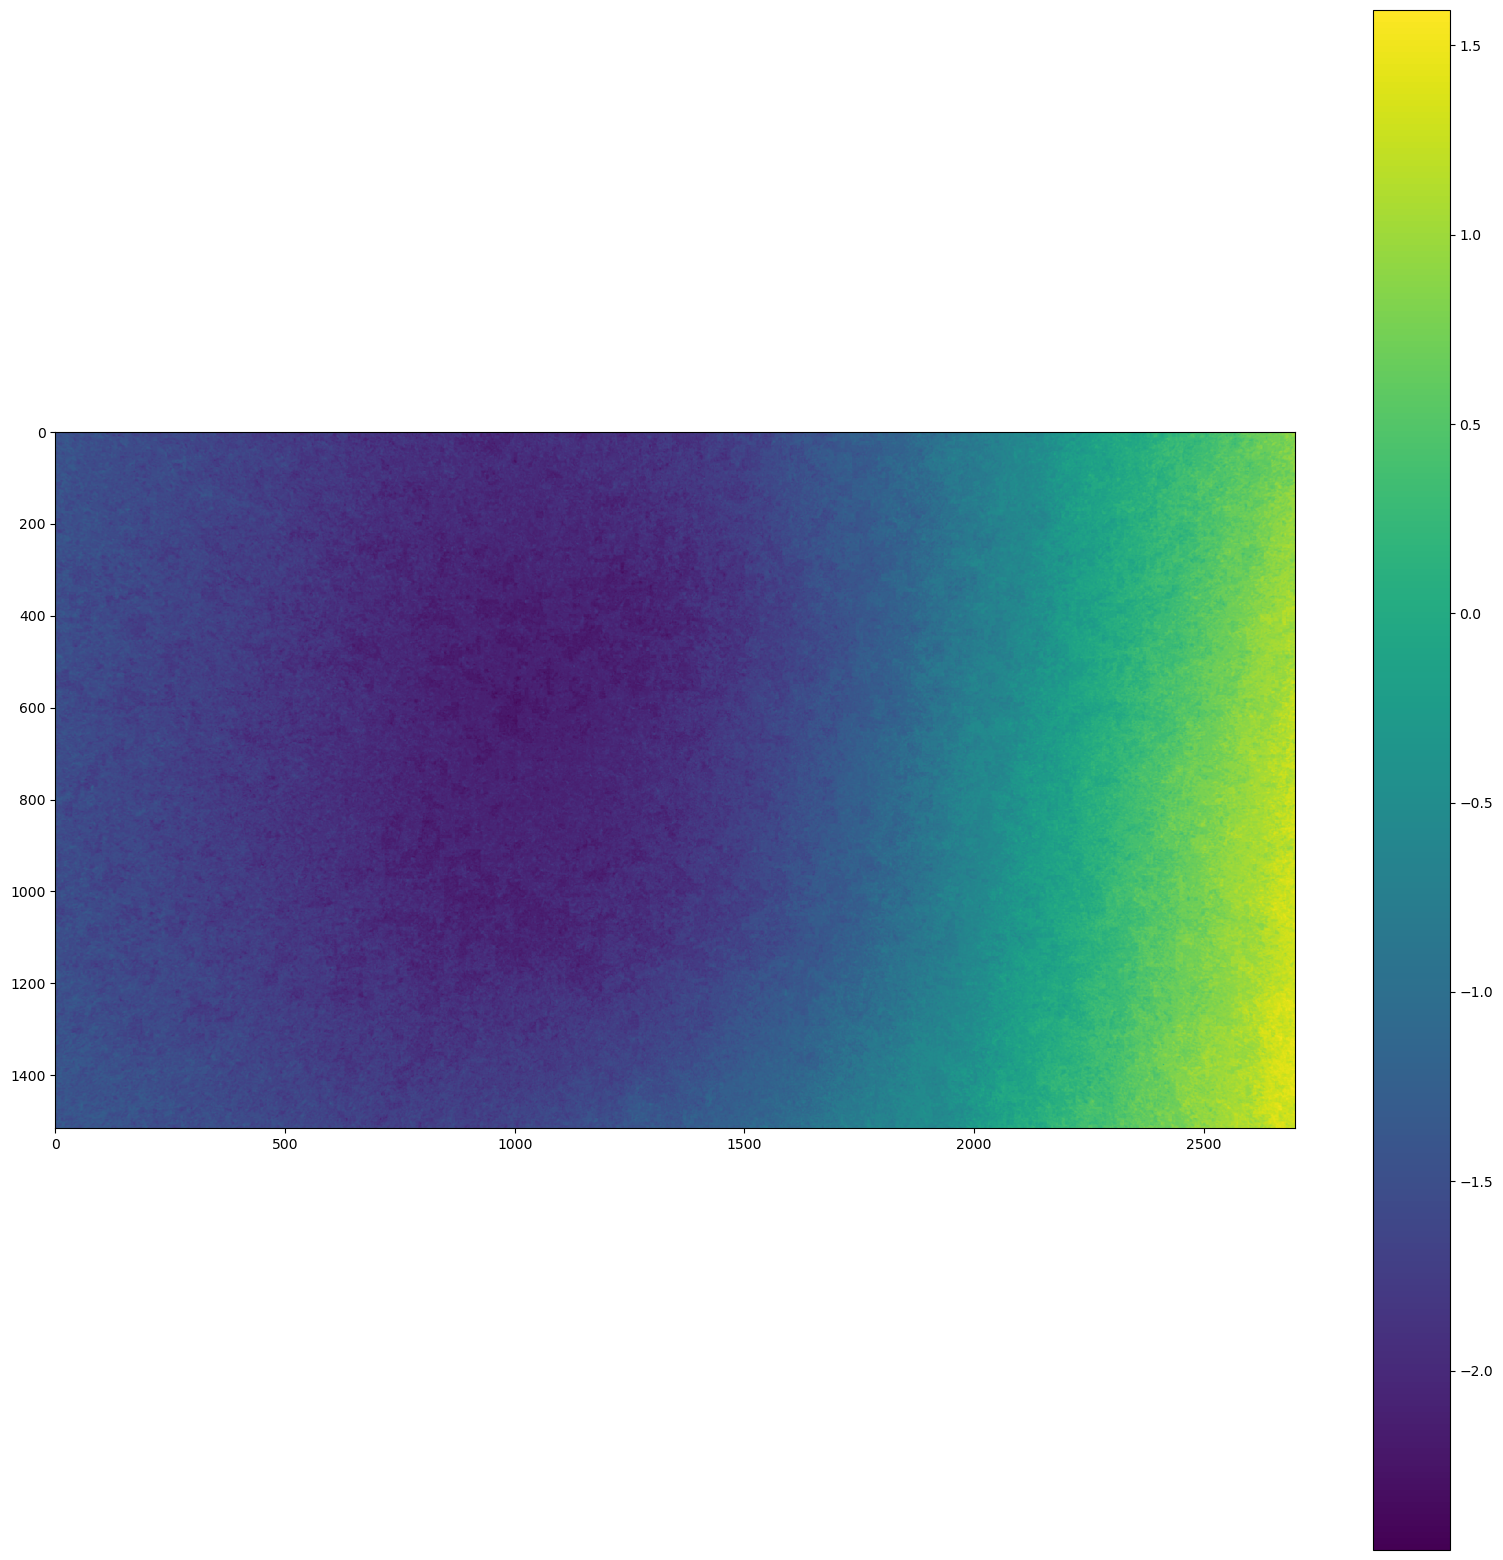

In [13]:
plt.figure(figsize=(20,20))
# plt.imshow(((np.squeeze(i['image']) - mean) / std)[:,:,1])
plt.imshow(np.squeeze(i['image']))
plt.colorbar()
# plt.figure(figsize=(20,20))


In [14]:
# save_folder
root_output_folder = 'D:\\kasanka-bats'
for bat_dataset in bat_datasets[:]:
    #print(bat_dataset['save_folder'])
    day = bat_dataset['save_folder'].split('\\')[-2]
    location = bat_dataset['save_folder'].split('\\')[-1]
    save_folder = os.path.join(root_output_folder, day, location)
    print(save_folder)
    # print(os.path.join(save_folder, 'size.npy'))

D:\kasanka-bats\30-Oct-2020\Not Chingyangali
D:\kasanka-bats\30-Oct-2020\Fibwe Parking
D:\kasanka-bats\30-Oct-2020\Musola Parking
D:\kasanka-bats\30-Oct-2020\Chinyangali
D:\kasanka-bats\30-Oct-2020\Fibwe Public
D:\kasanka-bats\30-Oct-2020\Puku
D:\kasanka-bats\30-Oct-2020\Musola Path


In [15]:
def logit2prob(logit):
    e_l = np.e ** logit
    return e_l 

def denorm_image(im, mean, std):
    """ Take image the was normalized and return to 0 to 255"""
#     im = np.copy(im)
    im *= std
    im += mean
    im *= 255
    im = np.maximum(im, 0)
    im = np.minimum(im, 255)
    im = im.astype(np.uint8)
    
    return im

should_plot = False
should_save = True

num_classes = 2
bat_prob_thresh = .6
batch_size = 1
#2
early_stop = None
# save some original frames to check detection quality
save_every_n_frames = 1350
channel = 2


device = torch.device("cuda")
model = UNETTraditional(1, 2, should_pad=False)
model.load_state_dict(torch.load(model_file))
model.to(device)

model.train(False)

for bat_dataset in bat_datasets[:]:

    num_frames = 0
    running_loss = 0
    
    print(bat_dataset['save_folder'])
    
    dataloader = data.DataLoader(bat_dataset['dataset'], 
                                 batch_size=batch_size,
                                 shuffle=False, num_workers=0, 
                                 pin_memory=True)

    centers_list = []
    contours_list = []
    sizes_list = []
    rects_list = []


    for batch_ind, batch in enumerate(dataloader):
        if batch_ind == 0:
            print('started...')
            t0 = time.time()
        if early_stop:
            if batch_ind >= early_stop:
                break

        im_batch = batch['image'].cuda()
    #     masks = batch['mask'].cuda()

        with torch.no_grad():
            outputs = model(im_batch)
            masks = (outputs[:, 1].cpu().numpy() > np.log(bat_prob_thresh)).astype(np.uint8)
            
            for ind, mask in enumerate(masks):
                centers, areas, contours, _, _, rects = bat_functions.get_blob_info(mask)
                centers_list.append(centers)
                sizes_list.append(areas)
                contours_list.append(contours)
                rects_list.append(rects)
                if save_every_n_frames:
                    if num_frames % save_every_n_frames == 0:
                        day = bat_dataset['save_folder'].split('\\')[-2]
                        card = bat_dataset['save_folder'].split('\\')[-1]
                        # day = bat_dataset['save_folder'].split('\\')[-2]
                        # location = bat_dataset['save_folder'].split('\\')[-1]
                        save_folder = os.path.join(root_output_folder, day, card)
                        im_name = '{}_{}_obs-ind_{}.jpg'.format(day, card, num_frames)
                        im_file = os.path.join(save_folder, 
                                               'example-frames', im_name)
                        im = np.squeeze(batch['image'][ind].numpy())
                        im = denorm_image(im, mean[channel]/255, std[channel]/255)
                        cv2.imwrite(im_file, im)
                num_frames += 1


        if should_plot:
            for ind in range(len(im_batch)):

                if 'orig' in batch.keys():
                    plt.figure(figsize=(10,10))
                    plt.imshow(batch['orig'][ind])
                plt.figure(figsize=(10,10))
                im = im_batch[ind].cpu().numpy()
                im = np.transpose(im, (1, 2, 0))
                plt.imshow(im)
                plt.figure(figsize=(10,10))
                im = outputs[ind][0].cpu().numpy()
                plt.imshow(im)
                plt.title('output')
                prob = logit2prob(outputs[ind,1].cpu().numpy())
                mask = (prob > 0.5).astype(np.uint8)

    #             display_im = np.zeros_like(im)
    #             display_im[..., 0] = masks[ind]
                plt.figure(figsize=(10,10))
                plt.imshow(mask)
    #             plt.colorbar()
    #             plt.figure(figsize=(10,10))
    #             plt.imshow(display_im)

    total_time = time.time() - t0
    print(total_time, total_time / batch_ind / batch_size)
    print(bat_dataset['dataset'].get_read_frame_info())
    if should_save:
        day = bat_dataset['save_folder'].split('\\')[-2]
        location = bat_dataset['save_folder'].split('\\')[-1]
        save_folder = os.path.join(root_output_folder, day, location)
        # save_folder = bat_dataset['save_folder']
        num_contour_files = 15
        file_num = 0
        new_contours = []
        for frame_ind, cs in enumerate(contours_list):
            if frame_ind % int(len(contours_list)/num_contour_files) == 0:
                # start new file
                file_name = f'contours-compressed-{file_num:02d}.npy'
                file = os.path.join(save_folder, file_name)
                np.save(file, np.array(new_contours, dtype=object))
                new_contours = []
                file_num += 1
            new_contours.append([])
            for c in cs:
                cc	= np.squeeze(cv2.approxPolyDP(c, 0.1, closed=True))
                new_contours[-1].append(cc)
        file_name = f'contours-compressed-{file_num:02d}.npy'
        file = os.path.join(save_folder, file_name)
        np.save(file, np.array(new_contours, dtype=object))
        np.save(os.path.join(save_folder, 'size.npy'), sizes_list)
        np.save(os.path.join(save_folder,'rects.npy'), rects_list)
        np.save(os.path.join(save_folder, 'centers.npy'), centers_list)

D:\kasanka-bats\30-Oct-2020\Not Chingyangali
started...
video capture closed
video capture closed
9839.248332738876 0.4639404155384231
21210 frames have been read with 707 bad reads
None


C:\Users\Edward\anaconda3\envs\Eidolon\lib\site-packages\numpy\core\_asarray.py:171: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order, subok=True)


D:\kasanka-bats\30-Oct-2020\Fibwe Parking
started...
video capture closed
starting new video
20310 frames have been read with 402 bad reads
None
video capture closed
video capture closed
19621.416034936905 0.4830600466514908
40620 frames have been read with 1104 bad reads
None
D:\kasanka-bats\30-Oct-2020\Musola Parking
started...
video capture closed
starting new video
21270 frames have been read with 406 bad reads
None
too dark
video capture closed
16530.868183612823 0.4725400389792992
34985 frames have been read with 812 bad reads
None
D:\kasanka-bats\30-Oct-2020\Chinyangali
started...
video capture closed
starting new video
14490 frames have been read with 373 bad reads
None
video capture closed
starting new video
28980 frames have been read with 746 bad reads
None
video capture closed
video capture closed
29316.341044425964 0.6744194953743119
43470 frames have been read with 1419 bad reads
None
D:\kasanka-bats\30-Oct-2020\Fibwe Public
started...
video capture closed
starting new vi

In [16]:
# D:\kasanka-bats\221101 Bat Count\9 KK
torch.cuda.memory_stats()

OrderedDict([('active.all.allocated', 12574324),
             ('active.all.current', 78),
             ('active.all.freed', 12574246),
             ('active.all.peak', 87),
             ('active.large_pool.allocated', 12574172),
             ('active.large_pool.current', 2),
             ('active.large_pool.freed', 12574170),
             ('active.large_pool.peak', 11),
             ('active.small_pool.allocated', 152),
             ('active.small_pool.current', 76),
             ('active.small_pool.freed', 76),
             ('active.small_pool.peak', 76),
             ('active_bytes.all.allocated', 3329555783235584),
             ('active_bytes.all.current', 49786368),
             ('active_bytes.all.freed', 3329555733449216),
             ('active_bytes.all.peak', 5009480192),
             ('active_bytes.large_pool.allocated', 3329555778700288),
             ('active_bytes.large_pool.current', 47518720),
             ('active_bytes.large_pool.freed', 3329555731181568),
             (

In [17]:
torch.cuda.memory_summary()

'|===========================================================================|\n|                  PyTorch CUDA memory summary, device ID 0                 |\n|---------------------------------------------------------------------------|\n|            CUDA OOMs: 0            |        cudaMalloc retries: 1         |\n|===========================================================================|\n|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |\n|---------------------------------------------------------------------------|\n| Allocated memory      |  48619 KiB |   4777 MiB |   3028 TiB |   3028 TiB |\n|       from large pool |  46405 KiB |   4775 MiB |   3028 TiB |   3028 TiB |\n|       from small pool |   2214 KiB |      2 MiB |      0 TiB |      0 TiB |\n|---------------------------------------------------------------------------|\n| Active memory         |  48619 KiB |   4777 MiB |   3028 TiB |   3028 TiB |\n|       from large pool |  46405 KiB |   4775 MiB |

In [18]:
torch.cuda.empty_cache()

In [19]:
torch.cuda.memory_stats()

OrderedDict([('active.all.allocated', 12574324),
             ('active.all.current', 78),
             ('active.all.freed', 12574246),
             ('active.all.peak', 87),
             ('active.large_pool.allocated', 12574172),
             ('active.large_pool.current', 2),
             ('active.large_pool.freed', 12574170),
             ('active.large_pool.peak', 11),
             ('active.small_pool.allocated', 152),
             ('active.small_pool.current', 76),
             ('active.small_pool.freed', 76),
             ('active.small_pool.peak', 76),
             ('active_bytes.all.allocated', 3329555783235584),
             ('active_bytes.all.current', 49786368),
             ('active_bytes.all.freed', 3329555733449216),
             ('active_bytes.all.peak', 5009480192),
             ('active_bytes.large_pool.allocated', 3329555778700288),
             ('active_bytes.large_pool.current', 47518720),
             ('active_bytes.large_pool.freed', 3329555731181568),
             (

In [20]:
# pip install GPUtil

In [21]:
import GPUtil
GPUtil.showUtilization()

| ID | GPU | MEM |
------------------
|  0 |  0% | 17% |


In [22]:
torch.cuda.empy_cache()

AttributeError: module 'torch.cuda' has no attribute 'empy_cache'

In [ ]:
import torch
from GPUtil import showUtilization as gpu_usage

print("Initial GPU Usage")
gpu_usage()                             

tensorList = []
for x in range(10):
  tensorList.append(torch.randn(10000000,10).cuda())   # reduce the size of tensor if you are getting OOM
  
  

print("GPU Usage after allcoating a bunch of Tensors")
gpu_usage()

del tensorList

print("GPU Usage after deleting the Tensors")
gpu_usage()  

print("GPU Usage after emptying the cache")
torch.cuda.empty_cache()
gpu_usage()